Quantum Gates and Bell State preparations 

Quantum gates are the fundamental building blocks of quantum circuits. They manipulate the state of qubits, enabling quantum computations and algorithms. Quantum gates are unitary operations, which means they preserve the total probability (the qubit remains in a valid quantum state).

Quantum gates:

1. Single-Qubit Gates:

 Operate on a single qubit at a time.
 Change the qubit state through operations such as rotations, bit-flips, or phase shifts.
Examples include Pauli gates (X, Y, Z), Hadamard (H), phase gates (S, T), and general rotation gates (Rx, Ry, Rz).

2. Multi-Qubit Gates:

Act on two or more qubits simultaneously.
Enable entanglement and conditional operations.
Examples include CNOT, CZ, and Toffoli gates.

Bell State Preparations:

Bell states are maximally entangled two-qubit states. They cannot be created using single-qubit gates alone; entangling gates like the CNOT gate are required. All four Bell states can be generated from the initial two-qubit ground state ∣00⟩.

1. Φ⁺ (Phi Plus): ∣Φ+⟩=(∣00⟩+∣11⟩)/2 
Preparation: Start from ∣00⟩, apply a Hadamard (H) gate on the first qubit, then a CNOT gate (first qubit control, second qubit target).

2. Φ⁻ (Phi Minus): |Φ⁻⟩=(∣00⟩−∣11⟩)/2
Preparation: Start from Φ⁺, then apply a Z gate on the first qubit to introduce a negative phase.

3. Ψ⁺ (Psi Plus): ∣Ψ+⟩=(∣01⟩+∣10⟩)/2
Preparation: Apply X on the first qubit of |00>, then Hadamard on the first qubit, followed by CNOT. Then, apply X on the first qubit of Φ⁺.

5. Ψ⁻ (Psi Minus): ∣Ψ−⟩=(∣01⟩−∣10⟩)/2
Preparation: Apply X on the first qubit of |00>, then Hadamard on the first qubit, followed by CNOT. Then, apply X on the first qubit of Φ⁺.then apply a Z gate on the first qubit to introduce a negative phase.

Key Notes:
Single-qubit gates are especially important because they form the foundation of all quantum circuits, allowing us to perform precise rotations on the Bloch sphere, control superpositions, and combine with multi-qubit gates to implement complex algorithms.
Bell states are maximally entangled, so measuring one qubit immediately determines the state of the other.
Single-qubit gates alone cannot create entanglement; a two-qubit entangling gate (like CNOT) is required.


NOT (X) Pauli gate

The Pauli-X gate, also known as the NOT gate, performs a bit-flip operation similar to the classical NOT gate. However, in quantum mechanics, it goes beyond classical logic because it acts as a rotation on the Bloch sphere. Specifically, the X gate corresponds to a π radian (180°) rotation about the X-axis.

This means that when the gate is applied to a qubit in the state ∣1⟩, it flips it to the state ∣0⟩. On the Bloch sphere, this operation moves the state vector from pointing down along the Z-axis (for ∣1⟩) to up along the Z-axis (for ∣0⟩). This rotational view is crucial for understanding single-qubit operations in quantum computing. 



In [1]:
import qutip as qt 
import numpy as np

import sys
import os

# Python path so notebook can find bell_state
sys.path.insert(0, os.path.abspath("src"))

from bell_state.operators import (
    I, X, Y, Z, H, S, T, P0, P1,
    controlled_gate, projectors, U_N_qubits, U_one_gate, U_two_gates,
    ket0, ket1, ket_plus, ket_minus, rotation_gate
)

Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [1.+0.j 0.+0.j]


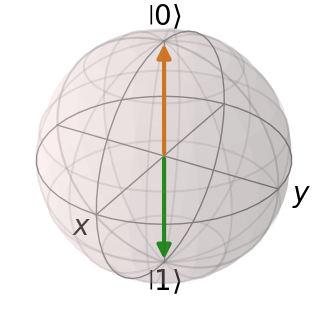

In [2]:
#Prepare initial state
initial_state = ket1()  
final_state = X @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()

The Pauli-X (bit-flip) gate was applied to a single qubit initially prepared in the state ∣1⟩. Using the qutip.sigmax() operator, the output was successfully verified as ∣0⟩, demonstrating the bit-flip transformation ∣1⟩→∣0⟩ and Bloch sphere visualization

Y Pauli gate

The Pauli-Y gate represents a rotation around the Y-axis by π radians (180°) on the Bloch sphere. It acts similarly to the Pauli-X gate by flipping the qubit state, but with an additional phase shift.

When the input state is ∣1⟩, the Y gate produces an output of i∣1⟩; and when the input is ∣1⟩, it gives −i∣0⟩. This phase factor (i or −i) distinguishes the Y gate from the X gate and highlights the complex nature of quantum state transformations. Thus, while both X and Y gates perform bit-flips, the Y gate introduces a phase rotation, reflecting the inherently quantum behavior of qubits.

Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.-1.j 0.+0.j]


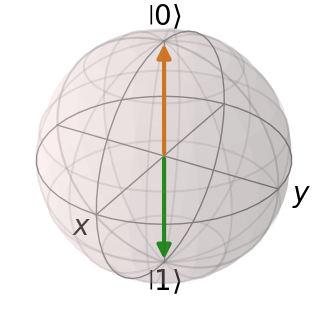

In [3]:
#Prepare initial state
initial_state = ket1()  
final_state = Y @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()

The Pauli-Y gate was applied to an initial state ∣1⟩. The resulting state was −i∣0⟩, confirming the expected bit-flip with a phase shift.

The Bloch sphere visualization showed the same directional flip as the X gate, a rotation of 180° from ∣1⟩ to ∣0⟩. The visualization appeared identical to the X gate case because the global phase introduced by the Y gate does not affect measurement outcomes.

Z Pauli gate

The Pauli-Z gate represents a rotation around the Z-axis by π radians (180°) on the Bloch sphere. Unlike the X and Y gates, it does not flip the qubit state between ∣0⟩ and ∣1⟩. Instead, it changes the phase of the ∣1⟩ component of the state by multiplying it by −1. This means that when the gate is applied to a qubit in the state ∣0⟩, the output remains ∣0⟩, while for an input state ∣1⟩, the output becomes −∣1⟩. The Pauli-Z gate therefore performs a phase-flip rather than a bit-flip, altering the relative phase between the computational basis states.

Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [ 0.+0.j -1.+0.j]


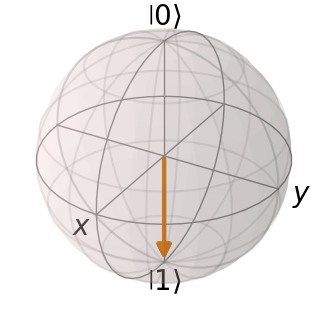

In [4]:
#Prepare initial state
initial_state = ket1()  
final_state = Z @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()

The Pauli-Z gate was applied to a qubit initially prepared in the state ∣1⟩. The resulting state was −∣1⟩. On the Bloch sphere, this corresponds to a 180° rotation around the Z-axis, causing the state vector to point in the opposite direction within the equatorial plane. The Bloch sphere visualization clearly showed the phase rotation, distinguishing it from the X and Y gates that involve flips between the poles.

Hadamard (H) Gate

The H gate acts as a toggle (or bridge) between the X and Z bases. It transforms the qubit state from the computational basis states ∣0⟩ and ∣1⟩ into the superposition (Hadamard) basis states ∣+⟩ and ∣−⟩. This operation is fundamental in quantum computing because it enables the formation of equal superposition states that are essential for most quantum algorithms.

Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [ 0.70710678+0.j -0.70710678+0.j]


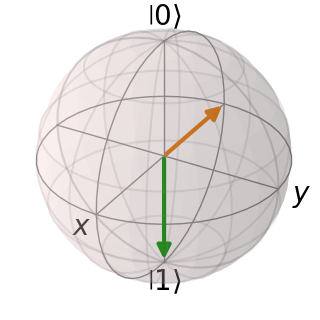

In [5]:
#Prepare initial state
initial_state = ket1()  
final_state = H @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()

The Hadamard gate was applied to the qubit initially in the state ∣1⟩. The resulting state was ∣−⟩, which represents an equal superposition of ∣0⟩ and ∣1⟩ with a relative negative phase:
                      H∣1⟩=∣−⟩
On the Bloch sphere, this transformation corresponds to moving the state vector from the south pole (representing ∣1⟩) to a point on the equatorial plane. This shows that the qubit is now in a balanced superposition oriented along the negative X-axis

S Gate (Phase Gate)

The S gate, also known as the phase gate, performs a rotation of π/2 (90°) about the Z-axis on the Bloch sphere. It is similar to the Z gate, but instead of flipping the phase by π, it introduces a smaller phase shift of π/2. The S gate does not change the probability amplitudes of measuring ∣0⟩ or ∣1⟩; rather, it changes the relative phase between them.

Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.+0.j 0.+1.j]


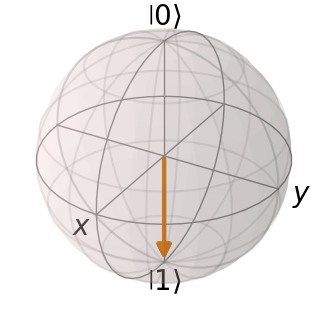

In [6]:
#Prepare initial state
initial_state = ket1()  
final_state = S @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


The S gate was applied to a qubit initially in the state ∣1⟩. The resulting state was i∣1⟩, confirming that the S gate introduces a 90° phase shift to the ∣1⟩ component while leaving ∣0⟩ unchanged:

    S∣1⟩=i∣1⟩
On the Bloch sphere, this transformation corresponds to a rotation around the Z-axis by π/2, meaning the state vector remains pointing downward but gains a phase rotation in the complex plane. This demonstrates that the S gate changes only the phase of the state, not its measurement probabilities.

T gate(π/8 Gate)

T gate is the same as the S gate, only the rotation is π/4. This means that the ∣0⟩ state remains unchanged, while the ∣1⟩ state acquires a phase factor of e(iπ/4). The truth table shows that the T gate rotates the state vector around the Z-axis by π/4: if the input is ∣0⟩, the output remains ∣0⟩, but if the input is ∣1⟩, the output becomes e(iπ/4)∣1⟩, introducing a 45° phase shift.

Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.        +0.j         0.70710678+0.70710678j]


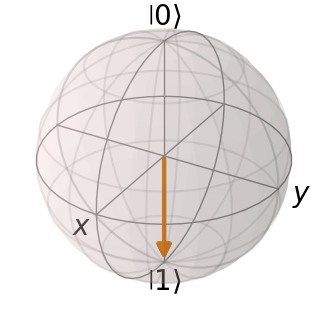

In [7]:
#Prepare initial state
initial_state = ket1()  
final_state = T @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()

The T gate is a phase gate that rotates by 45° around the Z axis. This phase shift is crucial for quantum interference and algorithm design, even though it does not affect measurement probabilities directly.

Applying the T gate to ∣1⟩ introduces a global phase of e(iπ/4), which does not affect measurement outcomes or the Bloch sphere visualization. The state appears unchanged. 

General Rotational Gates in Quantum Computing

In quantum computing, rotational gates are used to rotate a qubit state around an axis on the Bloch sphere by a specified angle. These rotations are fundamental because they allow arbitrary single-qubit transformations, which are essential for building any quantum algorithm. 

Using Euler's formula for matrices, the general rotation gate can also be written as:

Rot^n^(θ)=cos(θ/2)I−isin(θ/2)(^n^⋅σ)

This formula allows you to compute the effect of a rotation around any axis ^n^ by any angle 𝜃.


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.        -0.70710678j 0.70710678+0.j        ]


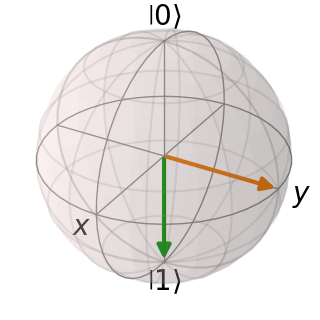

In [8]:
#Define the parameters
theta = np.pi /2             
axis = [1, 0, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [-0.70710678+0.j  0.70710678+0.j]


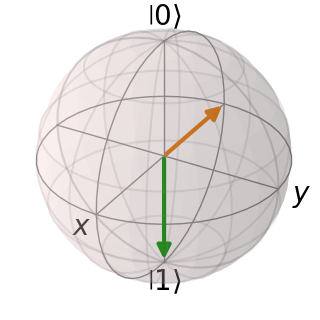

In [9]:
#Define the parameters
theta = np.pi /2             
axis = [0, 1, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.        +0.j         0.70710678+0.70710678j]


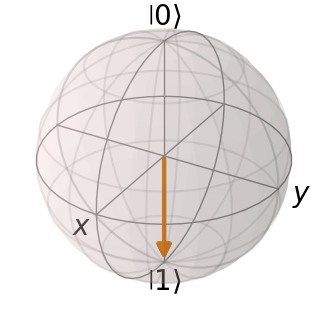

In [10]:
#Define the parameters
theta = np.pi /2             
axis = [0, 0, 1]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.        -0.38268343j 0.92387953+0.j        ]


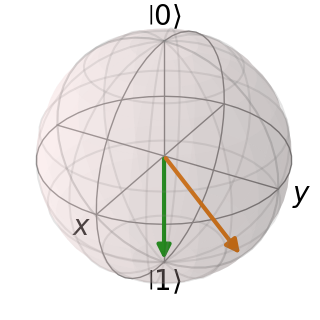

In [11]:
#Define the parameters
theta = np.pi /4             
axis = [1, 0, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [-0.38268343+0.j  0.92387953+0.j]


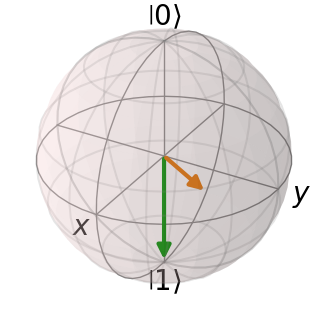

In [12]:
#Define the parameters
theta = np.pi /4           
axis = [0, 1, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.        +0.j         0.92387953+0.38268343j]


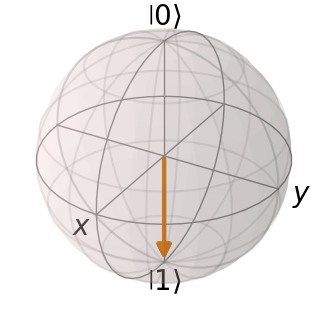

In [13]:
#Define the parameters
theta = np.pi /4            
axis = [0, 0, 1]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.000000e+00-1.j 6.123234e-17+0.j]


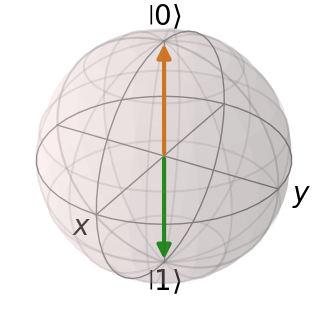

In [14]:
#Define the parameters
theta = np.pi             
axis = [1, 0, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [-1.000000e+00+0.j  6.123234e-17+0.j]


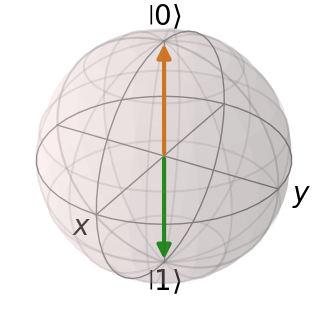

In [15]:
#Define the parameters
theta = np.pi             
axis = [0, 1, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.000000e+00+0.j 6.123234e-17+1.j]


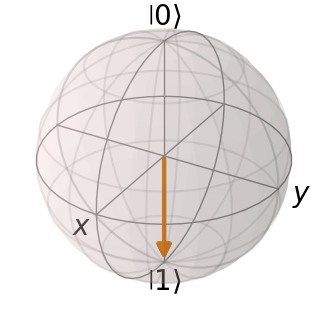

In [16]:
#Define the parameters
theta = np.pi             
axis = [0, 0, 1]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()

Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.        +0.j 0.70710678+0.j]


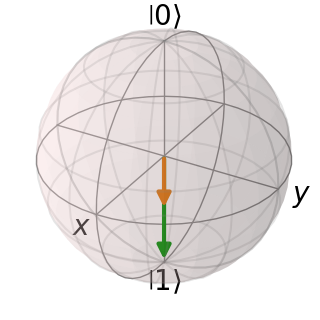

In [17]:
#Define the parameters
theta = np.pi /2             
axis = [0, 0, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [1.+0.j 0.+0.j]

Final State:
 [0.70710678+0.j         0.        -0.70710678j]


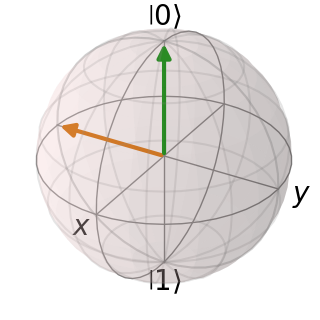

In [18]:
#Define the parameters
theta = np.pi /2             
axis = [1, 0, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket0()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [-0.70710678+0.j  0.70710678+0.j]


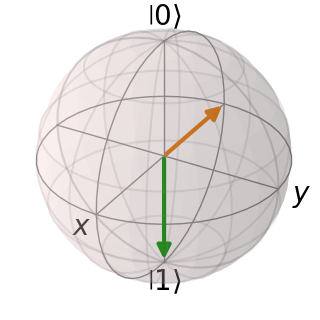

In [19]:
#Define the parameters
theta = np.pi /2             
axis = [0, 1, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.+0.j 1.+0.j]

Final State:
 [0.        +0.j         0.70710678+0.70710678j]


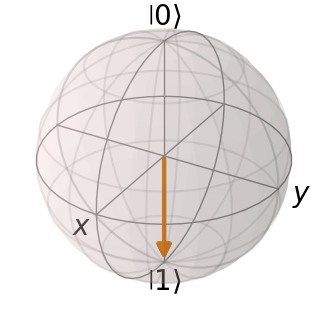

In [20]:
#Define the parameters
theta = np.pi /2             
axis = [0, 0, 1]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket1()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.70710678+0.j 0.70710678+0.j]

Final State:
 [0.5-0.5j 0.5-0.5j]


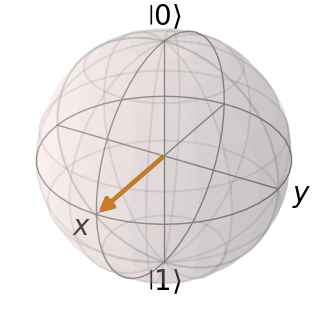

In [21]:
#Define the parameters
theta = np.pi /2             
axis = [1, 0, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket_plus()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.70710678+0.j 0.70710678+0.j]

Final State:
 [1.11022302e-16+0.j 1.00000000e+00+0.j]


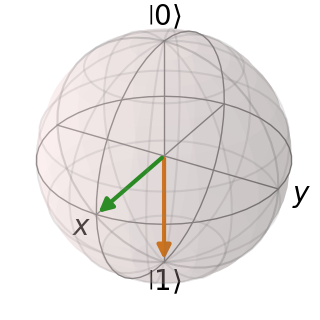

In [22]:
#Define the parameters
theta = np.pi /2             
axis = [0, 1, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket_plus()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.70710678+0.j 0.70710678+0.j]

Final State:
 [0.5-0.5j 0.5+0.5j]


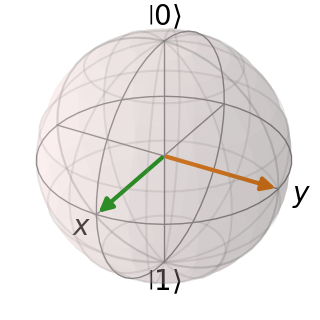

In [23]:
#Define the parameters
theta = np.pi /2             
axis = [0, 0, 1]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket_plus()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [ 0.70710678+0.j -0.70710678+0.j]

Final State:
 [ 0.5+0.5j -0.5-0.5j]


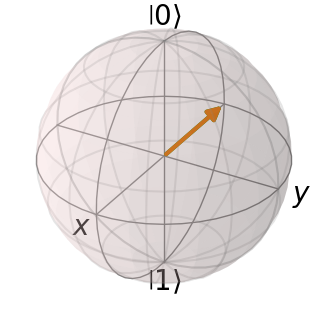

In [24]:
#Define the parameters
theta = np.pi /2             
axis = [1, 0, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket_minus()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.70710678+0.j 0.70710678+0.j]

Final State:
 [1.11022302e-16+0.j 1.00000000e+00+0.j]


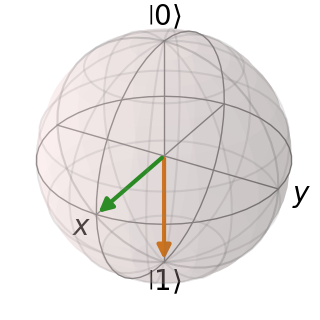

In [25]:
#Define the parameters
theta = np.pi /2             
axis = [0, 1, 0]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket_plus()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()


Initial State:
 [0.70710678+0.j 0.70710678+0.j]

Final State:
 [0.5-0.5j 0.5+0.5j]


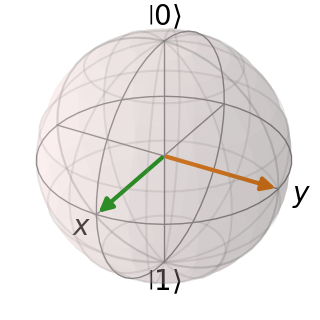

In [26]:
#Define the parameters
theta = np.pi /2             
axis = [0, 0, 1]               
R = rotation_gate(theta, axis)

#Prepare initial state
initial_state = ket_plus()  
final_state =  R @ initial_state

# Convert to Qobj for Bloch visualization
initial_qobj = qt.Qobj(initial_state)
final_qobj = qt.Qobj(final_state)
print("Initial State:\n", initial_state)
print()
print("Final State:\n", final_state)

#Bloch visualization
b = qt.Bloch(figsize=(3, 3))
b.add_states([initial_qobj, final_qobj])
b.show()

The general single-qubit rotation gate allows you to rotate a qubit state around any arbitrary axis 𝑛=(𝑛𝑥,𝑛𝑦,𝑛𝑧) by an angle 𝜃. This is the most general form of a single-qubit unitary rotation and includes all standard rotations (X, Y, Z, phase gates) as special cases.



Φ⁺ (Phi Plus)

To prepare Φ⁺, starts from the two-qubit ground state ∣00⟩. A Hadamard gate is applied to the first qubit, creating an equal superposition ∣0⟩ and ∣1⟩ for qubit, resulting in (∣00⟩+∣10⟩)/2. Then, a CNOT gate is applied with the first qubit as the control and the second qubit as the target. This operation entangles the qubits, yielding the final Φ⁺ state (∣00⟩+∣11⟩)/2
	​


In [27]:
import numpy as np

encoded_state = np.kron(ket0(), ket0()) 
H_op = np.kron(H, I)
state_after_H = H_op @ encoded_state
CNOT = controlled_gate(X, 0, 1, N=2)  
phi_plus_state = CNOT @ state_after_H 
print("Initial state:", encoded_state)
print()
print("Φ⁺ (Phi Plus):", phi_plus_state)

Initial state: [1.+0.j 0.+0.j 0.+0.j 0.+0.j]

Φ⁺ (Phi Plus): [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


In [28]:
import numpy as np

encoded_state = np.kron(ket0(), ket0()) 
H1 = np.kron(H, H)
state_after_H1 = H1 @ encoded_state
CZ = controlled_gate(Z, 0, 1, 2)
state_after_CZ = CZ @ state_after_H1
H_final = np.kron(I, H)
phi_plus= H_final @ state_after_CZ

print("Initial state:", encoded_state)
print()
print("Φ⁺ (Phi Plus):", phi_plus)

Initial state: [1.+0.j 0.+0.j 0.+0.j 0.+0.j]

Φ⁺ (Phi Plus): [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


##  Circuit Optimizations / Variants

This section explores **different circuits to prepare the same Bell state** and highlights ways to optimize quantum circuits.



### Key Concepts
Initial State: Bell states start |00⟩ 


### CNOT Approach
  1. Apply Hadamard (H) to the first qubit → creates superposition.
  2. Apply CNOT (control = qubit 0, target = qubit 1) → creates entanglement.
      Key Point:  Minimal gate count for Φ⁺; intuitive for beginners.

### Controlled-Z (CZ) Approach
  1. Apply H to both qubits.
  2. Apply controlled-Z (CZ) → entangles qubits in a different basis.
  3. Apply final H to the second qubit → converts state to Φ⁺.
    Key Point: Demonstrates alternative entangling gates and basis changes.

###Important Related Topics

1. Gate Equivalence:
   - CNOT and CZ are equivalent up to local Hadamard transformations.
   - Helps understand how the same quantum state can be represented differently.
2. Minimal Gates / Optimization:
   - Use only essential gates to reduce errors on real hardware.
   - Compare circuits to find shortest depth and fewest gates.
3. Bell State Variants:
   - Φ⁺, Φ⁻, Ψ⁺, Ψ⁻ can all be generated from |00⟩, |01⟩, |10⟩, and |11⟩ with appropriate H and CNOT/CZ gates.
4. Circuit Visualization:
   - Visual diagrams can improve understanding.
   - Showing different circuit layouts for the same state is great for teaching.
5. State Verification:
   - Verify using `np.allclose()` or measurement probabilities.
   - Ensures that optimization does not change the intended state.
6. Hardware Considerations:
   - Fewer gates → less decoherence → higher fidelity.
   - CZ may be native to some hardware (like superconducting qubits).

Φ⁺ (Phi Plus) is the first Bell state, defined as Φ+=(∣00⟩+∣11⟩)/2. It is a maximally entangled two-qubit state where measuring one qubit immediately determines the other. Starting from ∣00⟩, applying a Hadamard gate on the first qubit followed by a CNOT gate (first qubit control, second qubit target) creates Φ⁺. Its state vector components are 0.7071 for ∣00⟩ and ∣11⟩ and 0 for ∣01⟩ and ∣10⟩.

Φ⁻ (Phi Minus)

To Preparation, Starting from ∣00⟩, apply a Hadamard gate on the first qubit, creating (∣00⟩+∣10⟩)/2. Then apply a CNOT gate with the first qubit as control and the second qubit as target to get (∣00⟩+∣11⟩)/(Φ⁺). Finally, applying a Z gate on the first qubit introduces the negative phase, producing Φ⁻: (∣00⟩−∣11⟩)/2. ∣Φ-⟩=(∣00⟩−∣11⟩)/2 Like Φ⁺, it is a maximally entangled two-qubit state, but with a negative relative phase between the ∣00⟩ and ∣11⟩ components. 



In [29]:
import numpy as np

encoded_state = np.kron(ket1(), ket0()) 
H_op = np.kron(H, I)
state_after_H = H_op @ encoded_state
CNOT = controlled_gate(X, 0, 1, N=2)  
phi_minus_state = CNOT @ state_after_H
print("Initial state:", encoded_state)
print()
print("Φ⁻ (Phi minus):", phi_minus_state)

Initial state: [0.+0.j 0.+0.j 1.+0.j 0.+0.j]

Φ⁻ (Phi minus): [ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]


Φ⁻ is a maximally entangled two-qubit state with a negative relative phase between ∣00⟩ and ∣11⟩. Its state vector components are 0.7071 for ∣00⟩, -0.7071 for ∣11⟩, and 0 for ∣01⟩ and ∣10⟩. Like Φ⁺, measuring one qubit instantly determines the state of the other, demonstrating entanglement.

Ψ⁺ (Psi Plus)

To prepare Ψ⁺, start from the two-qubit ground state ∣00⟩. Apply an X gate on the first qubit, which flips it to ∣10⟩. Then, apply a Hadamard gate on the first qubit, creating an equal superposition of ∣0⟩ and ∣1⟩ for the first qubit, resulting in (∣00⟩+∣10⟩)/2. Finally, apply a CNOT gate with the first qubit as the control and the second as the target. This operation entangles the qubits, yielding the final Ψ⁺ state (∣01⟩+∣10⟩)/2.

In [30]:
import numpy as np

encoded_state = np.kron(ket0(), ket1()) 
H_op = np.kron(H, I)
state_after_H = H_op @ encoded_state
CNOT = controlled_gate(X, 0, 1, N=2)  
Psi_Plus_state = CNOT @ state_after_H 
print("Initial state:", encoded_state)
print()
print("Ψ⁺ (Psi Plus):", Psi_Plus_state)

Initial state: [0.+0.j 1.+0.j 0.+0.j 0.+0.j]

Ψ⁺ (Psi Plus): [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]


Ψ⁺ (Psi Plus) is a maximally entangled two-qubit state, where the qubits are always opposite: if one qubit is 0, the other is 1. Its state vector components are 0.7071 for ∣01⟩ and ∣10⟩, and 0 for ∣00⟩ and ∣11⟩.

Ψ⁻ (Psi Minus)

To prepare Ψ⁻, start from the Ψ⁺ state. Apply a Z gate on the first qubit to introduce a negative relative phase between ∣01⟩ and ∣10⟩. This yields the final Ψ⁻ state (∣01⟩−∣10⟩)/2.

In [31]:
import numpy as np

encoded_state = np.kron(ket1(), ket1()) 
H_op = np.kron(H, I)
state_after_H = H_op @ encoded_state
CNOT = controlled_gate(X, 0, 1, N=2)  
Psi_minus_state = CNOT @ state_after_H 
print("Initial state:", encoded_state)
print()
print("Ψ⁻ (Psi Plus):", Psi_minus_state)

Initial state: [0.+0.j 0.+0.j 0.+0.j 1.+0.j]

Ψ⁻ (Psi Plus): [ 0.        +0.j  0.70710678+0.j -0.70710678+0.j  0.        +0.j]


Ψ⁻ (Psi Minus) is also a maximally entangled two-qubit state, but differs from Ψ⁺ by a negative relative phase. Its state vector components are 0.7071 for ∣01⟩, -0.7071 for ∣10⟩, and 0 for ∣00⟩ and ∣11⟩. Measuring one qubit immediately determines the state of the other.